---
tags: [algorithm, sample-based]
---

# Quantum Selected Configuration Interaction (QSCI)

**QSCI**は量子状態からサンプリングしたビット列を使って小さな有効ハミルトニアンを構築し、それを古典コンピュータで厳密に対角化するハイブリッド量子・古典アルゴリズムです。素のVQEと比べた利点は、結果が厳密な**変分原理の保証**を引き継ぐ点にあります。ノイズのあるハードウェア上でも、

$$
E_{\mathrm{QSCI}} \;\geq\; E_{\mathrm{exact}}.
$$

Kanno *et al.*{cite:p}`10.48550/arXiv.2302.11320`が導入した4ステップのレシピは次のとおりです:

1. 量子コンピュータ上で入力状態$|\psi_{\mathrm{in}}\rangle$を準備する（典型的には大まかに最適化されたVQE状態）。
2. $|\psi_{\mathrm{in}}\rangle$を計算基底で多数回測定する。
3. 出現頻度が高い上位$K$個のビット列を離散部分空間$\{|s_i\rangle\}_{i=1}^{K}$として選ぶ。
4. 有効ハミルトニアン$H^{\mathrm{sub}}_{ij} = \langle s_i | H | s_j \rangle$を構築し、古典的に対角化する。

このチュートリアルでは4量子ビットの横磁場Isingモデルでフローを通しで歩きます。量子状態の準備とサンプリングは**QURI Parts**連携（Qulacsシミュレータ）で実行し、部分空間の構築と対角化は`qamomile.linalg.solve_subspace`を使います。内部ではベクトル化されたZ基底ルーチン`subspace_hamiltonian`（XOR・パリティ計算のみで行列積不要）を呼びます。

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize

import qamomile.circuit as qmc
import qamomile.observable as qm_o
from qamomile.circuit.algorithm.basic import cx_entangling_layer, ry_layer
from qamomile.linalg import solve_subspace
from qamomile.quri_parts import QuriPartsExecutor, QuriPartsTranspiler

docs_test_mode = os.environ.get("QAMOMILE_DOCS_TEST") == "1"

## 小さなテスト用ハミルトニアン

オープンチェーン上の4量子ビット横磁場Isingモデルを使います:

$$
H \;=\; -J \sum_{i=0}^{n-2} Z_i Z_{i+1} \;-\; h \sum_{i=0}^{n-1} X_i,
\quad J = 1,\; h = 0.7.
$$

16次元のヒルベルト空間は十分小さいので、NumPyで厳密な基底状態エネルギーを直接計算してQSCIのリファレンスとして使えます。

In [2]:
n_qubits = 4
J = 1.0
h_field = 0.7

H = qm_o.Hamiltonian(num_qubits=n_qubits)
for i in range(n_qubits - 1):
    H += qm_o.Z(i) * qm_o.Z(i + 1) * (-J)
for i in range(n_qubits):
    H += qm_o.X(i) * (-h_field)

exact_eigvals = np.linalg.eigvalsh(H.to_numpy())
E_exact = float(exact_eigvals[0])
print(f"Exact ground state energy: {E_exact:.6f}")
# eigvalsh は昇順で固有値を返すので exact_eigvals[0] が基底状態。
# 4 量子ビット TFIM のヒルベルト空間は 2^n_qubits 次元。
assert H.num_qubits == n_qubits
assert exact_eigvals.shape == (2**n_qubits,)
assert E_exact == float(exact_eigvals.min())

Exact ground state energy: -3.872983


## ハードウェア効率の良いansatz

単純な交互レイヤー型ansatzで、各レイヤーは全量子ビットへの$R_y$と線形チェーンのCXゲートを適用し、最後にもう一度$R_y$レイヤーを置きます。3つのヘルパーカーネルを定義します:

- `ansatz_state`は$|\psi(\theta)\rangle$の量子ビットレジスタを構築します
- `ansatz_energy`はVQE用に$\langle\psi|H|\psi\rangle$を返します
- `ansatz_measure`はQSCIサンプリング用に状態を計算基底で測定します

In [3]:
@qmc.qkernel
def ansatz_state(
    n: qmc.UInt,
    reps: qmc.UInt,
    thetas: qmc.Vector[qmc.Float],
) -> qmc.Vector[qmc.Qubit]:
    q = qmc.qubit_array(n, name="q")
    for r in qmc.range(reps):
        q = ry_layer(q, thetas, r * n)
        q = cx_entangling_layer(q)
    final_base = reps * n
    q = ry_layer(q, thetas, final_base)
    return q


@qmc.qkernel
def ansatz_energy(
    n: qmc.UInt,
    reps: qmc.UInt,
    thetas: qmc.Vector[qmc.Float],
    H: qmc.Observable,
) -> qmc.Float:
    q = ansatz_state(n, reps, thetas)
    return qmc.expval(q, H)


@qmc.qkernel
def ansatz_measure(
    n: qmc.UInt,
    reps: qmc.UInt,
    thetas: qmc.Vector[qmc.Float],
) -> qmc.Vector[qmc.Bit]:
    q = ansatz_state(n, reps, thetas)
    return qmc.measure(q)

## 両方のカーネルをQURI Partsでコンパイル

In [4]:
transpiler = QuriPartsTranspiler()
executor = QuriPartsExecutor()

reps = 2
n_params = (reps + 1) * n_qubits

energy_exec = transpiler.transpile(
    ansatz_energy,
    bindings={"n": n_qubits, "reps": reps, "H": H},
    parameters=["thetas"],
)
sample_exec = transpiler.transpile(
    ansatz_measure,
    bindings={"n": n_qubits, "reps": reps},
    parameters=["thetas"],
)

## ステップ1: 短いVQEで$|\psi_{\mathrm{in}}\rangle$を準備

QSCIは入力状態の最適化が甘くても頑健で、ランダムパラメータでも意味のある部分空間が得られますが、短いVQEを走らせるとサンプリング分布が真の基底状態を支配するビット列に集中するため、同じ$K$でも部分空間の情報量が大きくなります。ここでは数回のCOBYLA反復だけ走らせます。

In [5]:
def cost_fn(params: np.ndarray) -> float:
    return energy_exec.run(executor, bindings={"thetas": list(params)}).result()


rng = np.random.default_rng(0)
init_params = rng.uniform(0, 2 * np.pi, n_params)
assert init_params.shape == (n_params,)

maxiter = max(n_params + 2, 5 if docs_test_mode else 80)
result = minimize(
    cost_fn,
    init_params,
    method="COBYLA",
    options={"maxiter": maxiter, "rhobeg": 0.5},
)
opt_params = result.x
print(f"VQE energy = {result.fun:+.6f}   (gap to E_exact: {result.fun - E_exact:.4e})")
# 変分原理: COBYLA の予算がいくら短くても VQE エネルギーは E_exact の上界。
assert result.fun >= E_exact - 1e-9
assert opt_params.shape == (n_params,)

VQE energy = -3.719549   (gap to E_exact: 1.5343e-01)


## ステップ2: Z基底でビット列をサンプリング

各サンプルはタプル`(b_0, ..., b_{n-1})`で、$q$番目の要素は量子ビット$q$のZ固有値インデックスです。これは`subspace_hamiltonian`が期待する形式そのものです。

In [6]:
shots = 500 if docs_test_mode else 4000
sample_results = (
    sample_exec.sample(executor, bindings={"thetas": list(opt_params)}, shots=shots)
    .result()
    .results
)
sample_results.sort(key=lambda bc: bc[1], reverse=True)
print(f"Distinct bitstrings sampled: {len(sample_results)}")
for bits, c in sample_results[:5]:
    print(f"  {bits}  count={c}")
# 異なるビット列数はヒルベルト空間の次元を超えず、全ショットがカウントされ、
# 各ビット列は n_qubits 長。
assert len(sample_results) <= 2**n_qubits
assert sum(c for _, c in sample_results) == shots
assert all(len(bits) == n_qubits for bits, _ in sample_results)

Distinct bitstrings sampled: 14
  (1, 1, 1, 1)  count=2777
  (1, 1, 1, 0)  count=385
  (0, 1, 1, 1)  count=337
  (1, 0, 1, 1)  count=157
  (1, 1, 0, 1)  count=124


## ステップ3 + 4: QSCI部分空間の構築と対角化

各部分空間サイズ$K$について、出現頻度上位$K$個のビット列を`solve_subspace`に渡します。`solve_subspace`はベクトル化されたXOR・パリティルーチンで$H^{\mathrm{sub}}_{ij} = \langle s_i|H|s_j\rangle$を構築し、`numpy.linalg.eigh`を実行します。返ってくる最小固有値がQSCIエネルギーの推定値で、変分原理によって任意の$K$に対し$E_{\mathrm{QSCI}}(K) \geq E_{\mathrm{exact}}$が保証されます。

In [7]:
unique_bitstrings = [bits for bits, _ in sample_results]
K_max = len(unique_bitstrings)
ks = sorted({k for k in (1, 2, 4, 8, 16, K_max) if k <= K_max})

energies = [float(solve_subspace(unique_bitstrings[:K], H)[0][0]) for K in ks]

for K, E in zip(ks, energies):
    print(f"K = {K:3d}   E_QSCI = {E:+.6f}   gap = {E - E_exact:+.3e}")

assert all(E >= E_exact - 1e-9 for E in energies), "variational bound violated"
# Cauchy interlacing: 部分空間を広げると最小固有値は下がる (または変わらない) ので、
# QSCI エネルギーは K に対して単調非増加。
assert all(energies[i] >= energies[i + 1] - 1e-9 for i in range(len(energies) - 1))
assert len(energies) == len(ks)

K =   1   E_QSCI = -3.000000   gap = +8.730e-01
K =   2   E_QSCI = -3.220656   gap = +6.523e-01
K =   4   E_QSCI = -3.500753   gap = +3.722e-01
K =   8   E_QSCI = -3.682559   gap = +1.904e-01
K =  14   E_QSCI = -3.750479   gap = +1.225e-01


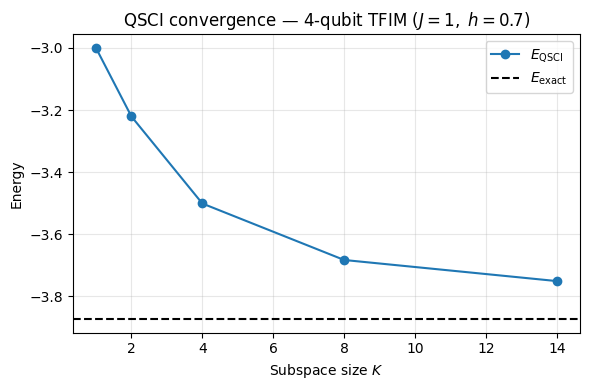

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ks, energies, "-o", label=r"$E_{\mathrm{QSCI}}$")
ax.axhline(E_exact, color="black", linestyle="--", label=r"$E_{\mathrm{exact}}$")
ax.set_xlabel("Subspace size $K$")
ax.set_ylabel("Energy")
ax.set_title("QSCI convergence — 4-qubit TFIM ($J{=}1,\\;h{=}0.7$)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 補足

- `solve_subspace`内部で使われるZ基底の高速経路（`subspace_hamiltonian`）は行列積を必要としません。各Pauli項は1つのXORマスクとパリティ符号として寄与し、$K^2$個のサンプルペア全体にわたってベクトル化されます。
- 重複したサンプルビット列は上記のunique-bitstringリストから除外されます。結果として得られる部分空間は条件数が良く、`solve_subspace`は通常のHermitian固有値分解を返します。